
# Level 2 – Task 3

## Feature Engineering

### Objective

The objective of this task is to create new meaningful features from the existing restaurant dataset to improve future machine learning models.

The analysis includes:

- Creating text-based features
- Encoding categorical variables
- Creating numerical features
- Creating binary features
- Preparing the dataset for predictive modeling

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [2]:
df = pd.read_csv("/Cleaned_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating Status
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Rated
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Rated
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Rated
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Rated
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Rated


In [4]:
df.shape

(9551, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [6]:
df["Restaurant Name Length"] = df["Restaurant Name"].str.len()

df[["Restaurant Name","Restaurant Name Length"]].head()

,Restaurant Name,Restaurant Name Length
0,Le Petit Souffle,16
1,Izakaya Kikufuji,16
2,Heat - Edsa Shangri-La,22
3,Ooma,4
4,Sambo Kojin,11


In [7]:
df["Address Length"] = df["Address"].str.len()

df[["Address","Address Length"]].head()

,Address,Address Length
0,"Third Floor, Century City Mall, Kalayaan Avenu...",71
1,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67
2,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56
3,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70
4,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64


In [8]:
df["Cuisine Count"] = df["Cuisines"].apply(
    lambda x: len(str(x).split(","))
)

df[["Cuisines","Cuisine Count"]].head()

,Cuisines,Cuisine Count
0,"French, Japanese, Desserts",3
1,Japanese,1
2,"Seafood, Asian, Filipino, Indian",4
3,"Japanese, Sushi",2
4,"Japanese, Korean",2


In [9]:
df["Table Booking"] = df["Has Table booking"].map({
    "Yes":1,
    "No":0
})

In [11]:
df["Online Delivery"] = df["Has Online delivery"].map({
    "Yes":1,
    "No":0
})

In [12]:
df["Delivering Now"] = df["Is delivering now"].map({
    "Yes":1,
    "No":0
})

In [13]:
df["Rating Status"] = np.where(
    df["Aggregate rating"]>0,
    "Rated",
    "Not Rated"
)

In [14]:
df["High Rated Restaurant"] = np.where(
    df["Aggregate rating"]>=4,
    1,
    0
)

In [15]:
df["Cost Per Person"] = (
    df["Average Cost for two"]/2
).round(2)

In [16]:
df["Log Votes"] = np.log1p(df["Votes"])

In [17]:
price_mapping = {
    1:"Budget",
    2:"Affordable",
    3:"Premium",
    4:"Luxury"
}

df["Price Category"] = df["Price range"].map(price_mapping)

In [18]:
df["Cost Category"] = pd.cut(
    df["Average Cost for two"],
    bins=[0,500,1000,3000,100000],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [19]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating Status,Restaurant Name Length,Address Length,Cuisine Count,Table Booking,Online Delivery,Delivering Now,High Rated Restaurant,Cost Per Person,Log Votes,Price Category,Cost Category
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Rated,16,71,3,1,0,0,1,550.0,5.752573,Premium,High
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Rated,16,67,1,1,0,0,1,600.0,6.383507,Premium,High
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Rated,22,56,4,1,0,0,1,2000.0,5.602119,Luxury,Very High
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Rated,4,70,2,0,0,0,1,750.0,5.902633,Luxury,High
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Rated,11,64,2,1,0,0,1,750.0,5.438079,Luxury,High


In [20]:
new_features = [

"Restaurant Name Length",

"Address Length",

"Cuisine Count",

"Table Booking",

"Online Delivery",

"Delivering Now",

"Rating Status",

"High Rated Restaurant",

"Cost Per Person",

"Log Votes",

"Price Category",

"Cost Category"

]

df[new_features].head()

,Restaurant Name Length,Address Length,Cuisine Count,Table Booking,Online Delivery,Delivering Now,Rating Status,High Rated Restaurant,Cost Per Person,Log Votes,Price Category,Cost Category
0,16,71,3,1,0,0,Rated,1,550.0,5.752573,Premium,High
1,16,67,1,1,0,0,Rated,1,600.0,6.383507,Premium,High
2,22,56,4,1,0,0,Rated,1,2000.0,5.602119,Luxury,Very High
3,4,70,2,0,0,0,Rated,1,750.0,5.902633,Luxury,High
4,11,64,2,1,0,0,Rated,1,750.0,5.438079,Luxury,High


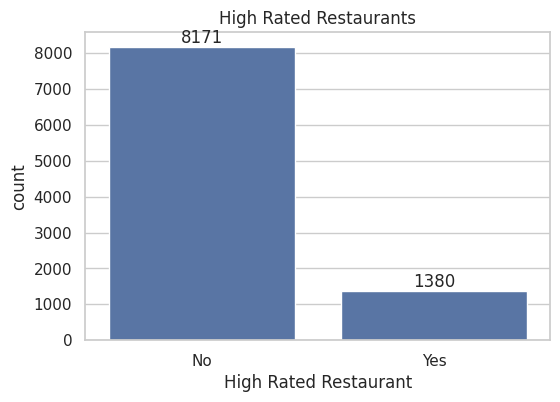

In [21]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="High Rated Restaurant"
)

plt.title("High Rated Restaurants")

plt.xticks(
    [0,1],
    ["No","Yes"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

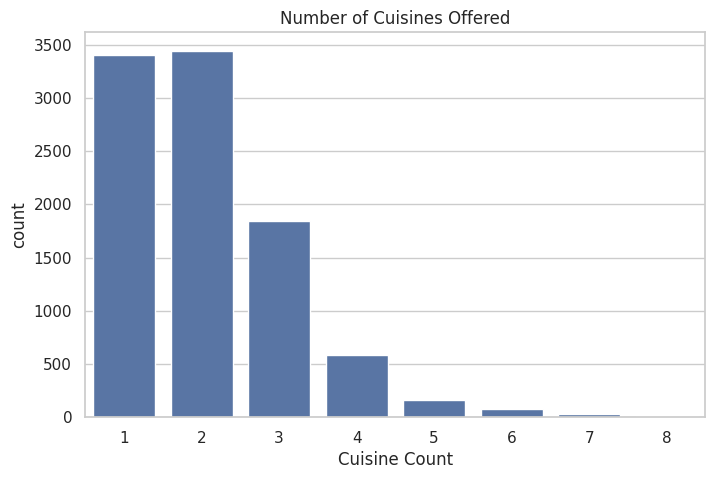

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Cuisine Count"
)

plt.title("Number of Cuisines Offered")

plt.show()

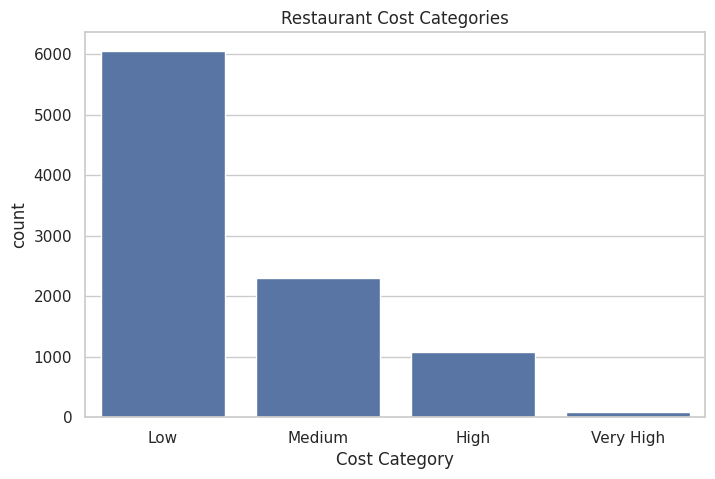

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Cost Category"
)

plt.title("Restaurant Cost Categories")

plt.show()

In [24]:
feature_summary = pd.DataFrame({

"Feature":[
"Restaurant Name Length",
"Address Length",
"Cuisine Count",
"Table Booking",
"Online Delivery",
"Delivering Now",
"Rating Status",
"High Rated Restaurant",
"Cost Per Person",
"Log Votes",
"Price Category",
"Cost Category"
],

"Purpose":[
"Text Length",
"Text Length",
"Number of cuisines",
"Binary Encoding",
"Binary Encoding",
"Binary Encoding",
"Target Grouping",
"Classification Target",
"Numerical Feature",
"Skew Reduction",
"Categorical Feature",
"Categorical Feature"
]

})

feature_summary

,Feature,Purpose
0,Restaurant Name Length,Text Length
1,Address Length,Text Length
2,Cuisine Count,Number of cuisines
3,Table Booking,Binary Encoding
4,Online Delivery,Binary Encoding
5,Delivering Now,Binary Encoding
6,Rating Status,Target Grouping
7,High Rated Restaurant,Classification Target
8,Cost Per Person,Numerical Feature
9,Log Votes,Skew Reduction


In [25]:
df.to_csv(
    "/content/Feature_Engineered_Dataset.csv",
    index=False
)

print("Feature Engineered Dataset Saved Successfully")

Feature Engineered Dataset Saved Successfully


# Business Insights

1. Feature engineering transformed raw restaurant data into meaningful variables that can improve predictive modeling.

2. Binary encoding converted categorical service features into machine-learning-friendly numerical values.

3. Cost per person provides a more interpretable pricing metric than average cost for two.

4. Cuisine count reflects restaurant diversity and can be useful in analyzing customer preferences.

5. Log transformation of votes reduces skewness and improves model stability.

6. Newly created features enhance the dataset for future regression and classification tasks.

# Conclusion

Feature engineering created several meaningful variables from the existing restaurant dataset. These engineered features improve data quality, simplify categorical information, and prepare the dataset for machine learning algorithms.

The transformed dataset is now more suitable for predictive modeling and advanced analytics while preserving the original information.